In [1]:
using Plots                          # Plotting
using CSV, DataFrames, JLD2          # Data handling
using LinearAlgebra, StatsBase       # Linear algebra, statistics
using Random, Statistics             # Random number generation, basic statistics
using LaTeXStrings                   # LaTeX support for plots
using Revise                          # Live code reloading

using StaticArrays, LazySets          # Efficient arrays, set operations
using Interpolations, LinearInterpolations  # Interpolation utilities
using SpatiotemporalGPs               # Gaussian processes
using DifferentialEquations, ForwardDiff # Differential equations, automatic differentiation
using Distributions, StatsPlots, SpecialFunctions, Glob # Wind Transformatoins


In [2]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")
include("../src/transects.jl")

┌ Warning: Replacing docs for `Main.Variograms.hp_fit :: Tuple{Any}` in module `Main.Variograms`
└ @ Base.Docs docs/Docs.jl:243


Main.Transects

In [3]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

# Mission domain
polygon_vertices = hcat(JordanLakeDomain.convex_polygon.vertices, JordanLakeDomain.convex_polygon.vertices[:, 1])  # Close the polygon
x0s = [@SVector[0.75, 0.75] for i=1:1]

# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours
ts_min = T_begin*60:dt_min:T_end*60


540.0:0.041666666666666664:720.0

In [4]:
# setup the spatial and temporal kernels
σt = 1.0   # m/s
σs = 1.0   # m/s
lt = 0.75*60.0  # minutes
# lt = 1000.0 * 60.0
ls = 0.75   # km

kt = Matern(1/2, σt, lt)
ks = Matern(1/2, σs, ls)

# Create spatial domain
# determine the spatial step size
dx = 0.05 # km

# create the spatial domain
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);

directory_prefix = "paper_plots"

"paper_plots"

In [5]:
# Load the JLD2 file
# file_path = "20251014_transect_1_5hr.jld2"
file_path = "20250630_transect_3hr_fixed1.jld2"
f = jldopen(file_path, "r")
transect_res_ergo_hp = f["res_ergo_hp"]
transect_synthetic_data = f["synthetic_data"]
transect_soc_target = f["soc_target"]
transect_ts_hrs = f["ts_hrs"]
transect_w_rated_val = f["w_rated_val"]
close(f)

# file_path = "20251014_ergo_1_5hr.jld2"
file_path = "20250630_ergo_3hr_fixed1.jld2"
f = jldopen(file_path, "r")
ergo_res_ergo_hp = f["res_ergo_hp"]
ergo_synthetic_data = f["synthetic_data"]
ergo_soc_target = f["soc_target"]
ergo_ts_hrs = f["ts_hrs"]
ergo_w_rated_val = f["w_rated_val"]
close(f)

In [ ]:
fields = fieldnames(typeof(transect_res_ergo_hp))
println(fields)

In [ ]:
println("target clarity length: ", length(ergo_res_ergo_hp.q_target_maps))
println("time length: ", length(ergo_res_ergo_hp.ts))
println("q map length: ", length(ergo_res_ergo_hp.ergo_q_maps))

In [ ]:
actual_wind_field = @animate for n = 1:10:length(ergo_res_ergo_hp.ts)-1
    heatmap(
        ergo_synthetic_data.xs,
        ergo_synthetic_data.ys,
        ergo_synthetic_data.data[:,:,n]',
        cmap = :balance,
        plottype = :wx,
        clims = (-5.0, 5.0),
        title = "Actual Wind Field"
    )
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw=2, linecolor="green")
end
gif(actual_wind_field, "$(directory_prefix)/synthetic_data_field.gif")


# Ergodic Summary Plots

In [ ]:
update_idxs = [t in ergo_res_ergo_hp.w_hat_ts ? 1 : 0 for t in ergo_res_ergo_hp.ts]
w_hat_idx = 1
measurement_val = []
estim_val = []
estim_dt = 10 # minutes

findnearest(A,x) = argmin(abs.(A .- x))

estim_vs_real_path = @animate for n = 1:10:length(ergo_res_ergo_hp.ts)-1
    plot()
    heatmap1 = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_synthetic_data.data[:,:,n]', cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    for i=1:length(x0s)
        idx = max(ergo_res_ergo_hp.ts[1], ergo_res_ergo_hp.ts[n] - estim_dt)
        new_idx = findnearest(ergo_res_ergo_hp.ts, idx)
        x = [r[i][1] for r in ergo_res_ergo_hp.xs[new_idx:n]]
        y = [r[i][2] for r in ergo_res_ergo_hp.xs[new_idx:n]]
        plot!(x, y, linewidth=3, color=:black, label=false)
    end
    plot!(clims=(-5.0,5.0))
    title!("Actual Wind Field")
    heatmap1 = plot!()
    if ergo_res_ergo_hp.ts[n] in ergo_res_ergo_hp.w_hat_ts
        global w_hat_idx = findfirst(isequal(ergo_res_ergo_hp.ts[n]), ergo_res_ergo_hp.w_hat_ts)
    end
    heatmap2 = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.w_hats[w_hat_idx]', cmap=:balance)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Estimated Wind Field")
    heatmap2 = plot!()

    # Clarity Plot
    claritymap = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Clarity")
    claritymap = plot!()

    # Error Plot
    targetmap = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.q_target_maps[n]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Target Clarity")
    targetmap = plot!()

    p = plot(heatmap1, heatmap2, claritymap, targetmap, layout=(2,2), plot_title="Time: $(Int(floor(ts_hrs[n]))):$(Int(floor(mod(ts_hrs[n],1)*60))) - w_rated_val:$(ergo_w_rated_val)")
    # p = plot(heatmap1, heatmap2, claritymap, layout=(1,3), plot_title="Time: $(Int(floor(ts_hrs[n]))):$(Int(floor(mod(ts_hrs[n],1)*60)))")


end
gif(estim_vs_real_path, "$(directory_prefix)/ergo_summary.gif")

In [ ]:
plot(ergo_res_ergo_hp.measurements)

In [ ]:
snapshot_idxs = round.(Int, LinRange(1, length(ergo_res_ergo_hp.ts)-1, 4))
for n in snapshot_idxs
    heatmap1 = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_synthetic_data.data[:,:,n]', cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Actual Wind Field")
    xlabel!("x [km]")
    ylabel!("y [km]")
    heatmap1 = plot!()

    w_hat_idx = findnearest(ergo_res_ergo_hp.w_hat_ts, ergo_res_ergo_hp.ts[n])
    println("ts: ", ergo_res_ergo_hp.ts[n])
    println("w_hat_idx: ", w_hat_idx)
    
    heatmap2 = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.w_hats[w_hat_idx]', cmap=:balance)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Estimated Wind Field")
    xlabel!("x [km]")
    ylabel!("y [km]")
    heatmap2 = plot!()

    claritymap = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Clarity")
    xlabel!("x [km]")
    ylabel!("y [km]")
    claritymap = plot!()

    targetmap = heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_res_ergo_hp.q_target_maps[n]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Target Clarity")
    xlabel!("x [km]")
    ylabel!("y [km]")
    targetmap = plot!()
    duration = round(ergo_ts_hrs[n] - ergo_ts_hrs[1], digits=2)
    p = plot(heatmap1, heatmap2, claritymap, targetmap, 
             layout=(2,2),
             plot_title="Duration: $(duration) hrs", 
             dpi=900, 
             size=(1200, 1200),
             left_margin=5Plots.mm,
             right_margin=5Plots.mm,
             top_margin=5Plots.mm,
             bottom_margin=5Plots.mm,
            )
    savefig(p, "$(directory_prefix)/ergo_summary_$(n).pdf")
end

# Transect Summary Plots

In [ ]:
update_idxs = [t in transect_res_ergo_hp.w_hat_ts ? 1 : 0 for t in transect_res_ergo_hp.ts]
w_hat_idx = 1
measurement_val = []
estim_val = []
estim_dt = 10 # minutes

findnearest(A,x) = argmin(abs.(A .- x))

estim_vs_real_path = @animate for n = 1:10:length(transect_res_ergo_hp.ts)-1
    plot()
    heatmap1 = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_synthetic_data.data[:,:,n]', cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    for i=1:length(x0s)
        idx = max(transect_res_ergo_hp.ts[1], transect_res_ergo_hp.ts[n] - estim_dt)
        new_idx = findnearest(transect_res_ergo_hp.ts, idx)
        x = [r[i][1] for r in transect_res_ergo_hp.xs[new_idx:n]]
        y = [r[i][2] for r in transect_res_ergo_hp.xs[new_idx:n]]
        plot!(x, y, linewidth=3, color=:black, label=false)
    end
    plot!(clims=(-5.0,5.0))
    title!("Actual Wind Field")
    heatmap1 = plot!()
    if transect_res_ergo_hp.ts[n] in transect_res_ergo_hp.w_hat_ts
        global w_hat_idx = findfirst(isequal(transect_res_ergo_hp.ts[n]), transect_res_ergo_hp.w_hat_ts)
    end
    heatmap2 = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.w_hats[w_hat_idx]', cmap=:balance)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Estimated Wind Field")
    heatmap2 = plot!()

    # Clarity Plot
    claritymap = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Clarity")
    claritymap = plot!()

    # Error Plot
    targetmap = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.q_target_maps[n]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Target Clarity")
    targetmap = plot!()

    p = plot(heatmap1, heatmap2, claritymap, targetmap, layout=(2,2), plot_title="Time: $(Int(floor(ts_hrs[n]))):$(Int(floor(mod(ts_hrs[n],1)*60))) - w_rated_val:$(transect_w_rated_val)")
    # p = plot(heatmap1, heatmap2, claritymap, layout=(1,3), plot_title="Time: $(Int(floor(ts_hrs[n]))):$(Int(floor(mod(ts_hrs[n],1)*60)))")


end
gif(estim_vs_real_path, "$(directory_prefix)/transect_summary.gif")

In [ ]:
plot(transect_res_ergo_hp.measurements)

In [ ]:
snapshot_idxs = round.(Int, LinRange(1, length(transect_res_ergo_hp.ts)-1, 4))
for n in snapshot_idxs
    heatmap1 = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_synthetic_data.data[:,:,n]', cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Actual Wind Field")
    xlabel!("x [km]")
    ylabel!("y [km]")
    heatmap1 = plot!()

    w_hat_idx = findnearest(transect_res_ergo_hp.w_hat_ts, transect_res_ergo_hp.ts[n])
    println("ts: ", transect_res_ergo_hp.ts[n])
    println("w_hat_idx: ", w_hat_idx)
    
    heatmap2 = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.w_hats[w_hat_idx]', cmap=:balance)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Estimated Wind Field")
    xlabel!("x [km]")
    ylabel!("y [km]")
    heatmap2 = plot!()

    claritymap = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Clarity")
    xlabel!("x [km]")
    ylabel!("y [km]")
    claritymap = plot!()

    targetmap = heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_res_ergo_hp.q_target_maps[n]')
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Target Clarity")
    xlabel!("x [km]")
    ylabel!("y [km]")
    targetmap = plot!()
    duration = round(transect_ts_hrs[n] - transect_ts_hrs[1], digits=2)
    p = plot(heatmap1, heatmap2, claritymap, targetmap, 
             layout=(2,2),
             plot_title="Duration: $(duration) hrs", 
             dpi=900, 
             size=(1200, 1200),
             left_margin=5Plots.mm,
             right_margin=5Plots.mm,
             top_margin=5Plots.mm,
             bottom_margin=5Plots.mm,
            )
    savefig(p, "$(directory_prefix)/transect_summary_$(n).pdf")
end

# Comparison Plots

## Energy Plots

In [ ]:
plot(transect_ts_hrs .- transect_ts_hrs[1], transect_soc_target, label="SOC Target", color="black", linewidth=2, linestyle=:dash, legend=:topleft)
plot!(ergo_ts_hrs .- transect_ts_hrs[1], ergo_res_ergo_hp.bs[1:end-1], label="Ergodic", color=1, linewidth=2)
plot!(transect_ts_hrs .- transect_ts_hrs[1], transect_res_ergo_hp.bs[1:end-1], label="Transect", color=2, linewidth=2)
title!("SOC vs Time")
xlabel!("Duration [hrs]")
ylabel!("SOC [Wh]")
socplot = plot!()

In [ ]:
plot(ergo_ts_hrs .- transect_ts_hrs[1], ergo_res_ergo_hp.speeds, label="Ergodic", color=1, linewidth=2)
plot!(transect_ts_hrs .- transect_ts_hrs[1], transect_res_ergo_hp.speeds, label="Transect", color=2, linewidth=2)
title!("Speed vs Time")
xlabel!("Duration [hrs]")
ylabel!("Speed [m/s]")
ylims!(0, 2.5)
hline!([2.315], label="Max Speed", color="black", linestyle=:dash)
speedplot = plot!()

In [ ]:
plot(socplot, speedplot, layout=(2,1), dpi=900)
savefig("$(directory_prefix)/soc_v_time_sim.pdf")
plot!()

## Information Plots

In [ ]:
ergo_clarity_deficit = similar(ergo_res_ergo_hp.q_target_maps');
for n = 1:length(ergo_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(ergo_res_ergo_hp.w_hat_ts, ergo_res_ergo_hp.ts[n])
    ergo_clarity_deficit[n] = max.(0, ergo_res_ergo_hp.q_target_maps[n]' .- ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    # ergo_clarity_deficit[n] = abs.(ergo_res_ergo_hp.q_target_maps[n]' .- ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end

transect_clarity_deficit = similar(transect_res_ergo_hp.q_target_maps');
for n = 1:length(transect_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(transect_res_ergo_hp.w_hat_ts, transect_res_ergo_hp.ts[n])
    transect_clarity_deficit[n] = max.(0, transect_res_ergo_hp.q_target_maps[n]' .- transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    # transect_clarity_deficit[n] = abs.(transect_res_ergo_hp.q_target_maps[n]' .- transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end

@gif for n = 1:50:length(ergo_res_ergo_hp.ts)-1
    heatmap(ergo_synthetic_data.xs, ergo_synthetic_data.ys, ergo_clarity_deficit[n], cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    ergo = title!("Ergodic Deficit")

    heatmap(transect_synthetic_data.xs, transect_synthetic_data.ys, transect_clarity_deficit[n], cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    transect = title!("Transect Deficit")

    plot(ergo, transect, layout=(1,2), size=(1200, 600))
end

In [ ]:
ergo_clarity_deficit = similar(ergo_res_ergo_hp.q_target_maps');
for n = 1:length(ergo_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(ergo_res_ergo_hp.w_hat_ts, ergo_res_ergo_hp.ts[n])
    ergo_clarity_deficit[n] = max.(0, ergo_res_ergo_hp.q_target_maps[n]' .- ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    # ergo_clarity_deficit[n] = abs.(ergo_res_ergo_hp.q_target_maps[n]' .- ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end

transect_clarity_deficit = similar(transect_res_ergo_hp.q_target_maps');
for n = 1:length(transect_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(transect_res_ergo_hp.w_hat_ts, transect_res_ergo_hp.ts[n])
    transect_clarity_deficit[n] = max.(0, transect_res_ergo_hp.q_target_maps[n]' .- transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
    # transect_clarity_deficit[n] = abs.(transect_res_ergo_hp.q_target_maps[n]' .- transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end

ergo_mean_deficit = [mean(ergo_clarity_deficit[n]) for n in 1:length(ergo_clarity_deficit)-1]
transect_mean_deficit = [mean(transect_clarity_deficit[n]) for n in 1:length(transect_clarity_deficit)-1]
durations = ergo_ts_hrs .- transect_ts_hrs[1];
plot(durations[1:end-1], ergo_mean_deficit, label="Ergodic", color=1, linewidth=2)
plot!(durations[1:end-1], transect_mean_deficit, label="Transect", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Mean Clarity Deficit")
title!("Mean Clarity Deficit vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/mean_clarity_deficit.png")
plot!()

In [ ]:
ergo_mean_clarity = [mean(ergo_res_ergo_hp.ergo_q_maps[n]) for n in 1:length(ergo_res_ergo_hp.ergo_q_maps)]
ergo_mean_target_clarity = [mean(ergo_res_ergo_hp.q_target_maps[n]) for n in 1:length(ergo_res_ergo_hp.q_target_maps)]
transect_mean_clarity = [mean(transect_res_ergo_hp.ergo_q_maps[n]) for n in 1:length(transect_res_ergo_hp.ergo_q_maps)]
transect_mean_target_clarity = [mean(transect_res_ergo_hp.q_target_maps[n]) for n in 1:length(transect_res_ergo_hp.q_target_maps)]


plot(ergo_mean_clarity, label="Ergodic Clarity", color=1, linewidth=2)
plot!(transect_mean_clarity, label="Transect Clarity", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Mean Clarity")
title!("Mean Clarity vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/mean_clarity.png")
plot!()

In [ ]:
plot(ergo_mean_target_clarity, label="Ergodic Clarity", color=1, linewidth=2)
plot!(transect_mean_target_clarity, label="Transect Clarity", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Mean Clarity")
title!("Mean Target Clarity vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/mean_target_clarity.png")
plot!()

In [ ]:
# Calculate total clarity deficit for each time step
ergo_total_clarity_deficit = [sum(ergo_clarity_deficit[n]) for n in 1:length(ergo_clarity_deficit)-1]
transect_total_clarity_deficit = [sum(transect_clarity_deficit[n]) for n in 1:length(transect_clarity_deficit)-1]

# Plot total clarity deficit as a function of time
plot(durations[1:end-1], ergo_total_clarity_deficit, label="Ergodic", color=1, linewidth=2)
plot!(durations[1:end-1], transect_total_clarity_deficit, label="Transect", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Total Clarity Deficit")
title!("Total Clarity Deficit vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/total_clarity_deficit_vs_time.png")
plot!()

In [ ]:
# Calculate total clarity for each time step
ergo_total_clarity = [sum(ergo_res_ergo_hp.ergo_q_maps[n]) for n in 1:length(ergo_res_ergo_hp.ergo_q_maps)]
transect_total_clarity = [sum(transect_res_ergo_hp.ergo_q_maps[n]) for n in 1:length(transect_res_ergo_hp.ergo_q_maps)]

# Plot total clarity as a function of time
plot(ergo_total_clarity, label="Ergodic", color=1, linewidth=2)
plot!(transect_total_clarity, label="Transect", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Total Clarity")
title!("Total Clarity vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/total_clarity.png")
plot!()

In [ ]:
# Calculate total target clarity for each time step
ergo_total_target_clarity = [sum(ergo_res_ergo_hp.q_target_maps[n]) for n in 1:length(ergo_res_ergo_hp.q_target_maps)]
transect_total_target_clarity = [sum(transect_res_ergo_hp.q_target_maps[n]) for n in 1:length(transect_res_ergo_hp.q_target_maps)]

# Plot total target clarity as a function of time
plot(durations, ergo_total_target_clarity, label="Ergodic", color=1, linewidth=2)
plot!(durations, transect_total_target_clarity, label="Transect", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Total Target Clarity")
title!("Total Target Clarity vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/total_target_clarity_vs_time.png")
plot!()

In [ ]:
# Calculate total clarity deficit for each time step
ergo_total_clarity_deficit = [sum(ergo_clarity_deficit[n]) for n in 1:length(ergo_clarity_deficit)-1]
transect_total_clarity_deficit = [sum(transect_clarity_deficit[n]) for n in 1:length(transect_clarity_deficit)-1]

# Plot total clarity deficit as a function of time
plot(durations[1:end-1], ergo_total_clarity_deficit, label="Ergodic", color=1, linewidth=2)
plot!(durations[1:end-1], transect_total_clarity_deficit, label="Transect", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Total Clarity Deficit")
title!("Total Clarity Deficit vs Time")
plot!(dpi=900)
savefig("$(directory_prefix)/total_clarity_deficit_vs_time.png")
plot!()

In [ ]:
# Ergodic Data
ergo_estimates_v_time = []
for n = 1:length(ergo_res_ergo_hp.ts)
    x = ergo_res_ergo_hp.xs[n][end][1]
    y = ergo_res_ergo_hp.xs[n][end][2]

    estim_idx = ergo_res_ergo_hp.ts[n]
    new_idx = findnearest(ergo_res_ergo_hp.w_hat_ts, estim_idx)
    itp = linear_interpolation((xs, ys), ergo_res_ergo_hp.w_hats[new_idx])
    push!(ergo_estimates_v_time, itp(x, y))
end

# Transect Data
transect_estimates_v_time = []
for n = 1:length(transect_res_ergo_hp.ts)
    x = transect_res_ergo_hp.xs[n][end][1]
    y = transect_res_ergo_hp.xs[n][end][2]

    estim_idx = transect_res_ergo_hp.ts[n]
    new_idx = findnearest(transect_res_ergo_hp.w_hat_ts, estim_idx)
    itp = linear_interpolation((xs, ys), transect_res_ergo_hp.w_hats[new_idx])
    push!(transect_estimates_v_time, itp(x, y))
end

# Plot real-time estimation error for Ergodic Data
plot(ergo_res_ergo_hp.measurements .- ergo_estimates_v_time, label=false, xlabel="Time (hrs)", ylabel="Error [m/s]", lw=2)
title!("Ergodic Real-time Estimation Error vs Time")
# savefig("ergo_realtime_estimation_error.png")
ergo_error = plot!()

# Plot real-time estimation error for Transect Data
plot(transect_res_ergo_hp.measurements .- transect_estimates_v_time, label=false, xlabel="Time (hrs)", ylabel="Error [m/s]", lw=2)
title!("Transect Real-time Estimation Error vs Time")
# savefig("transect_realtime_estimation_error.png")
transect_error = plot!()

plot(ergo_error, transect_error, layout=(2,1), dpi=900)

In [ ]:
# Define the time bins
estim_dt = 10 # minutes
time_bins = 0:0.5:estim_dt

# Function to calculate binned errors
function calculate_binned_errors(res_ergo_hp, xs, ys, time_bins, estim_dt)
    binned_errors = [Float64[] for _ in 1:length(time_bins)]
    for n = 1:length(res_ergo_hp.ts)
        x = res_ergo_hp.xs[n][end][1]
        y = res_ergo_hp.xs[n][end][2]
        for idx = res_ergo_hp.ts[n]:-0.01:max(res_ergo_hp.ts[1], res_ergo_hp.ts[n] - estim_dt)
            new_idx = findnearest(res_ergo_hp.w_hat_ts, idx)
            itp = linear_interpolation((xs, ys), res_ergo_hp.w_hats[new_idx])
            error = abs(res_ergo_hp.measurements[n] - itp(x, y))
            time_sep = res_ergo_hp.ts[n] - idx
            bin_idx = findnearest(time_bins, time_sep)
            push!(binned_errors[bin_idx], error)
        end
    end
    return binned_errors
end

# Calculate binned errors for ergodic data
ergo_binned_errors = calculate_binned_errors(ergo_res_ergo_hp, xs, ys, time_bins, estim_dt)
# Calculate binned errors for transect data
transect_binned_errors = calculate_binned_errors(transect_res_ergo_hp, xs, ys, time_bins, estim_dt)

# Calculate the average error for each bin
ergo_avg_binned_errors = [mean(errors) for errors in ergo_binned_errors if !isempty(errors)]
transect_avg_binned_errors = [mean(errors) for errors in transect_binned_errors if !isempty(errors)]

# Plot the average estimation error by binned time separation for ergodic data
scatter(time_bins, ergo_avg_binned_errors, label="Ergodic", color=1, xlabel="Time Separation [mins]", ylabel="Error [-]", lw=2)
# Plot the average estimation error by binned time separation for transect data
scatter!(time_bins, transect_avg_binned_errors, label="Transect", color=2, lw=2)
title!("Average Estimation Error \nby Binned Time Separation")
plot!(dpi=900)
savefig("$(directory_prefix)/avg_estimation_error_by_time_separation.pdf")
plot!()

In [ ]:
# Calculate average real-time errors for ergodic data
ergo_average_realtime_errors = ergo_res_ergo_hp.measurements .- ergo_estimates_v_time
# Plot histogram for ergodic data
histogram(ergo_average_realtime_errors, label="Ergodic Average Estimation Error", xlabel="Error [m/s]", ylabel="Frequency", lw=2)
title!("Ergodic Data - Mean: $(round(mean(ergo_average_realtime_errors), digits=2)), Std Dev: $(round(std(ergo_average_realtime_errors), digits=2))")
# savefig("ergo_estimation_error_histogram.png")
plot!()

# Calculate average real-time errors for transect data
transect_average_realtime_errors = transect_res_ergo_hp.measurements .- transect_estimates_v_time
# Plot histogram for transect data
histogram(transect_average_realtime_errors, label="Transect Average Estimation Error", xlabel="Error [m/s]", ylabel="Frequency", lw=2)
title!("Transect Data - Mean: $(round(mean(transect_average_realtime_errors), digits=2)), Std Dev: $(round(std(transect_average_realtime_errors), digits=2))")
# savefig("transect_estimation_error_histogram.png")
plot!()

# Coplot the histograms for comparison
histogram(ergo_average_realtime_errors, label="Ergodic Average Estimation Error", xlabel="Error [m/s]", ylabel="Frequency", lw=2, alpha=0.5, color="red")
histogram!(transect_average_realtime_errors, label="Transect Average Estimation Error", alpha=0.5, color="blue")
title!("Comparison of Average Estimation Errors")
plot!(dpi=900)

In [ ]:
# Calculate statistics for ergodic errors
ergo_mean_error = mean(ergo_average_realtime_errors)
ergo_std_error = std(ergo_average_realtime_errors)

# Calculate statistics for transect errors
transect_mean_error = mean(transect_average_realtime_errors)
transect_std_error = std(transect_average_realtime_errors)

# Print the statistics
println("Ergodic Errors - Mean: ", round(ergo_mean_error, digits=2), ", Std Dev: ", round(ergo_std_error, digits=2))
println("Transect Errors - Mean: ", round(transect_mean_error, digits=2), ", Std Dev: ", round(transect_std_error, digits=2))

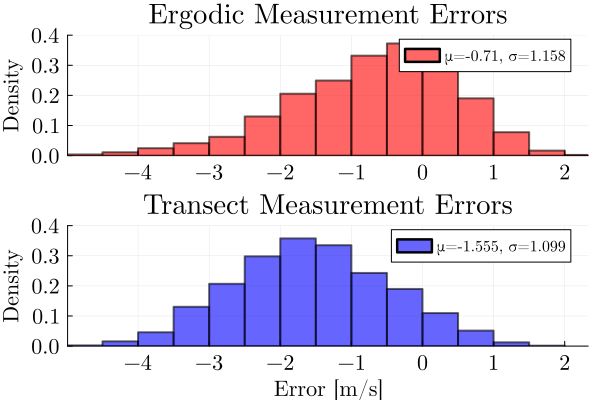

In [8]:
# Compute errors from rated speed
ergo_errors = ergo_res_ergo_hp.measurements .- ergo_w_rated_val
transect_errors = transect_res_ergo_hp.measurements .- transect_w_rated_val

# Statistics and labels
ergodic_mean = mean(ergo_errors); ergodic_std = std(ergo_errors)
transect_mean = mean(transect_errors); transect_std = std(transect_errors)
ergodic_label = "μ=$(round(ergodic_mean, digits=3)), σ=$(round(ergodic_std, digits=3))"
transect_label = "μ=$(round(transect_mean, digits=3)), σ=$(round(transect_std, digits=3))"

# Shared horizontal limits and vertical limits
xmin = min(minimum(ergo_errors), minimum(transect_errors))
xmax = max(maximum(ergo_errors), maximum(transect_errors))
xlims = (xmin, xmax)
ylims = (0, 0.4)

p1 = histogram(ergo_errors; bins=30, label=ergodic_label, alpha=0.6, normalize=true,
               xlims=xlims, ylims=ylims, ylabel="Density", title="Ergodic Measurement Errors", color=:red)
p2 = histogram(transect_errors; bins=30, label=transect_label, alpha=0.6, normalize=true,
               xlims=xlims, ylims=ylims, ylabel="Density", xlabel="Error [m/s]", title="Transect Measurement Errors", color=:blue)

combined = plot(p1, p2, layout=(2,1), link=:x)
savefig(joinpath(directory_prefix, "error_from_rated_histogram.png"))
plot!()


## Cross-Comparison

In [ ]:
ergo_target_transect_clarity_deficit = similar(ergo_res_ergo_hp.q_target_maps');
for n = 1:length(ergo_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(transect_res_ergo_hp.w_hat_ts, transect_res_ergo_hp.ts[n])
    ergo_target_transect_clarity_deficit[n] = max.(0, ergo_res_ergo_hp.q_target_maps[n]' .- transect_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end


transect_target_ergo_clarity_deficit = similar(transect_res_ergo_hp.q_target_maps');
for n = 1:length(transect_res_ergo_hp.ts)-1
    w_hat_idx = findnearest(ergo_res_ergo_hp.w_hat_ts, ergo_res_ergo_hp.ts[n])
    transect_target_ergo_clarity_deficit[n] = max.(0, transect_res_ergo_hp.q_target_maps[n]' .- ergo_res_ergo_hp.ergo_q_maps[w_hat_idx]')
end
ergo_target_transect_mean_deficit = [mean(ergo_target_transect_clarity_deficit[n]) for n in 1:length(ergo_target_transect_clarity_deficit)-1]
transect_target_ergo_mean_deficit = [mean(transect_target_ergo_clarity_deficit[n]) for n in 1:length(transect_target_ergo_clarity_deficit)-1]
durations = ergo_ts_hrs .- transect_ts_hrs[1];

plot(durations[1:end-1], ergo_target_transect_mean_deficit, label="Ergodic-Transect", color=1, linewidth=2)
plot!(durations[1:end-1], transect_target_ergo_mean_deficit, label="Transect-Ergodic", color=2, linewidth=2)
xlabel!("Duration [hrs]")
ylabel!("Mean Clarity Deficit")
title!("Cross Mean Clarity Deficit vs Time")
savefig("$(directory_prefix)/cross_mean_clarity_deficit.png")
plot!()